In [1]:
import json
import os
import warnings
from pathlib import Path
 
import numpy as np
import requests
from PIL import Image
from skimage.feature import hog
from skimage.transform import resize
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    average_precision_score,
    classification_report,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import MultiLabelBinarizer
 
warnings.filterwarnings("ignore")

/home/user/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [2]:
ANNOTATIONS_PATH = "dataset_annotations.json"
IMAGE_SIZE = (128, 128)   # размер, к которому приводятся все картинки
HOG_PIXELS_PER_CELL = (16, 16)
HOG_CELLS_PER_BLOCK = (2, 2)
COLOR_HIST_BINS = 32      # бинов на канал в цветовой гистограмме
TEST_SIZE = 0.2
RANDOM_STATE = 42

In [3]:
def load_annotations(path: str) -> dict:
    """Загружает JSON с аннотациями."""
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)
 
 
def parse_labels(annotations: dict) -> tuple[list[str], list[list[str]]]:
    image_paths = []

    item_labels = []
    color_labels = []
    style_labels = []
    season_labels = []

    for image_path, items in annotations.items():
        image_paths.append(image_path)

        items_set = set()
        colors_set = set()
        styles_set = set()
        seasons_set = set()

        for item_name, attrs in items.items():
            # item_type
            if attrs.get("item_type"):
                items_set.add(attrs["item_type"])

            # color (разбиваем!)
            if attrs.get("color"):
                colors = attrs["color"].lower().replace(",", "").split()
                colors_set.update(colors)

            # style
            if attrs.get("style"):
                styles_set.add(attrs["style"])

            # season
            if attrs.get("season"):
                seasons_set.add(attrs["season"])

        item_labels.append(list(items_set))
        color_labels.append(list(colors_set))
        style_labels.append(list(styles_set))
        season_labels.append(list(seasons_set))

    return image_paths, item_labels, color_labels, style_labels, season_labels

from collections import Counter

def count_labels(label_lists: list[list[str]]) -> Counter:
    counter = Counter()
    
    for labels in label_lists:
        counter.update(labels)
    
    return counter

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import spacy

nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])

def plot_label_distribution_seaborn(label_counts, title, top_n=20):
    # преобразуем в DataFrame
    df = pd.DataFrame(label_counts.items(), columns=["label", "count"])
    
    # сортировка
    df = df.sort_values(by="count", ascending=False).head(top_n)
    
    plt.figure(figsize=(10, 6))
    
    sns.barplot(
        data=df,
        y="label",
        x="count"
    )
    
    plt.title(f"ТОП {top_n} {title}")
    plt.xlabel("Count")
    plt.ylabel("Label")
    
    plt.tight_layout()
    plt.show()

def normalization_label(texts):
    # 1. Собираем все уникальные лейблы для батчинговой обработки
    unique_labels = {label.lower() for text in texts for label in text}
    
    # 2. Обрабатываем spaCy батчами (намного быстрее и эффективнее по памяти)
    # nlp.pipe возвращает генератор, мы собираем маппинг: оригинал -> лемма
    label_map = {}
    for doc in nlp.pipe(unique_labels, batch_size=1000):
        lemmas = ' '.join([token.lemma_ for token in doc])
        label_map[doc.text] = lemmas
            
    # 3. Собираем итоговую структуру с исправленным багом памяти
    texts_norm = []
    for text in texts:
        label_norm = []
        for label in text:
            label_lower = label.lower()
            label_norm.append(label_map[label_lower])
        texts_norm.append(label_norm)
        
    return texts_norm

In [5]:
print("── 1. Загрузка аннотаций ──────────────────────────────")
annotations = load_annotations(ANNOTATIONS_PATH)
image_paths, item_labels, color_labels, style_labels, season_labels = parse_labels(annotations)

item_labels = normalization_label(item_labels)
color_labels = normalization_label(color_labels)
style_labels = normalization_label(style_labels)
season_labels = normalization_label(season_labels)

print(f"  Изображений в датасете : {len(image_paths)}")

── 1. Загрузка аннотаций ──────────────────────────────
  Изображений в датасете : 15000


In [6]:
def get_all_labels(label_lists):
    return sorted({label for labels in label_lists for label in labels})


item_classes = get_all_labels(item_labels)
color_classes = get_all_labels(color_labels)
style_classes = get_all_labels(style_labels)
season_classes = get_all_labels(season_labels)

print(f"Item labels   : {len(item_classes)}")
print(f"Color labels  : {len(color_classes)}")
print(f"Style labels  : {len(style_classes)}")
print(f"Season labels : {len(season_classes)}")

Item labels   : 71
Color labels  : 45
Style labels  : 44
Season labels : 7


In [7]:
label_counts = count_labels(item_labels)

print(label_counts.most_common(10))  # топ-10

[('sweater', 14945), ('hat', 11422), ('shirt dress', 8370), ('dress', 6545), ('shoe', 4952), ('jacket', 4679), ('beanie', 3543), ('trouser', 2397), ('boot', 1510), ('pant', 944)]


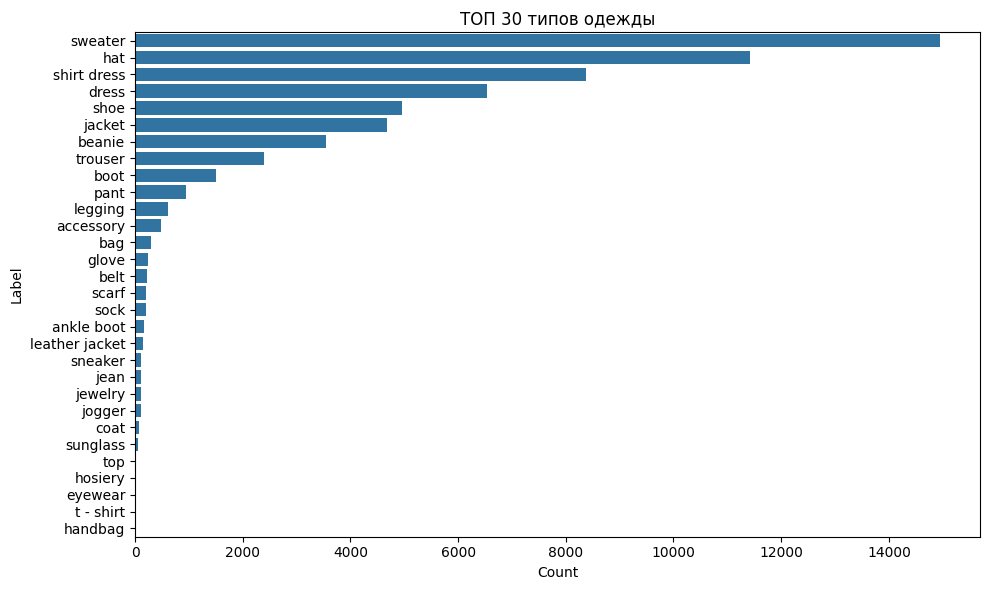

In [8]:
plot_label_distribution_seaborn(label_counts, 'типов одежды', 30)

In [9]:
def filter_labels(label_lists, min_count=20):
    counter = Counter(l for labels in label_lists for l in labels)

    valid = {l for l, c in counter.items() if c >= min_count}

    filtered = [
        [l for l in labels if l in valid]
        for labels in label_lists
    ]

    return filtered, valid

item_labels, item_valid = filter_labels(item_labels, 100)
color_labels, color_valid = filter_labels(color_labels, 100)
style_labels, style_valid = filter_labels(style_labels, 100)
season_labels, season_valid = filter_labels(season_labels, 100)

[('sweater', 14945), ('hat', 11422), ('shirt dress', 8370), ('dress', 6545), ('shoe', 4952), ('jacket', 4679), ('beanie', 3543), ('trouser', 2397), ('boot', 1510), ('pant', 944)]


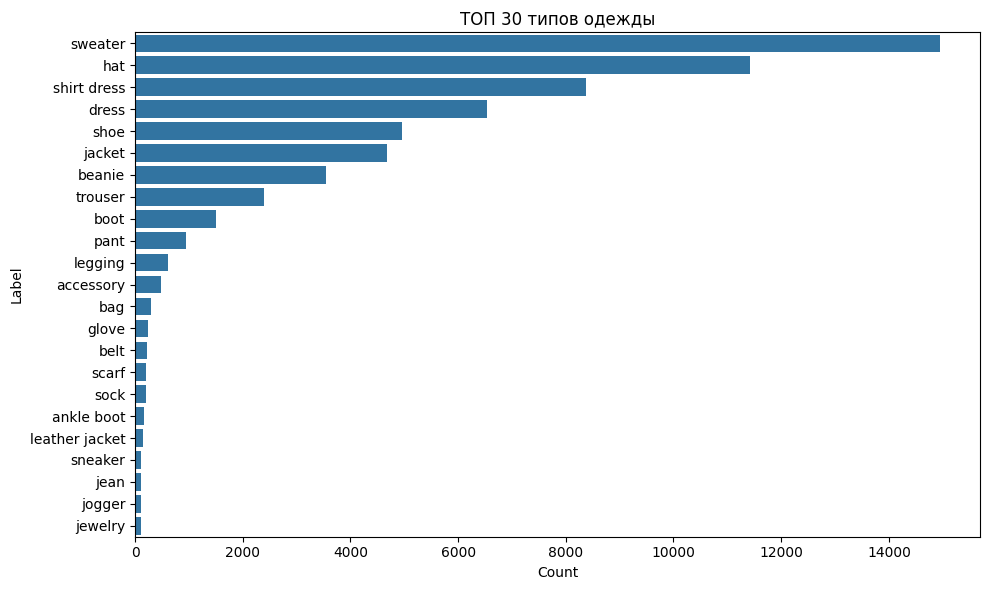

In [10]:
label_counts = count_labels(item_labels)

print(label_counts.most_common(10))  # топ-10

plot_label_distribution_seaborn(label_counts, 'типов одежды', 30)

In [11]:
def load_image(path: str) -> np.ndarray | None:
    """
    Загружает изображение с диска или по URL.
    Возвращает RGB-массив (H, W, 3) или None при ошибке.
    """
    # Попытка загрузить с диска
    if os.path.exists(path):
        try:
            img = Image.open(path).convert("RGB")
            return np.array(img)
        except Exception as e:
            print(f"  [!] Ошибка чтения файла {path}: {e}")
            return None
 
    # Попытка загрузить по URL (если путь — ссылка)
    if path.startswith("http"):
        try:
            response = requests.get(path, timeout=10)
            response.raise_for_status()
            img = Image.open(requests.utils.io.BytesIO(response.content)).convert("RGB")
            return np.array(img)
        except Exception as e:
            print(f"  [!] Ошибка загрузки {path}: {e}")
            return None
 
    print(f"  [!] Файл не найден: {path}")
    return None

In [12]:
def extract_hog_features(image: np.ndarray) -> np.ndarray:
    """
    HOG-признаки по всем трём RGB-каналам.
    Изображение предварительно масштабируется до IMAGE_SIZE.
    """
    img_resized = resize(image, IMAGE_SIZE, anti_aliasing=True)
 
    hog_channels = []
    for channel in range(3):
        features = hog(
            img_resized[:, :, channel],
            pixels_per_cell=HOG_PIXELS_PER_CELL,
            cells_per_block=HOG_CELLS_PER_BLOCK,
            feature_vector=True,
        )
        hog_channels.append(features)
 
    return np.concatenate(hog_channels)
 
 
def extract_color_histogram(image: np.ndarray) -> np.ndarray:
    """
    Нормированная гистограмма цветов по каждому RGB-каналу.
    Отражает общее распределение цветов на фото.
    """
    histograms = []
    for channel in range(3):
        hist, _ = np.histogram(
            image[:, :, channel],
            bins=COLOR_HIST_BINS,
            range=(0, 256),
        )
        hist = hist / (hist.sum() + 1e-6)  # нормализация
        histograms.append(hist)
 
    return np.concatenate(histograms)
 
 
def extract_features(image: np.ndarray) -> np.ndarray:
    """Объединяет HOG и цветовую гистограмму в единый вектор признаков."""
    hog_features = extract_hog_features(image)
    color_features = extract_color_histogram(image)
    return np.concatenate([hog_features, color_features])
 
 
from pathlib import Path
import numpy as np

def build_feature_matrix(image_paths: list[str]):
    """
    Загружает изображения и извлекает признаки.

    Возвращает:
        X              : матрица признаков
        valid_indices  : индексы успешно загруженных изображений
    """
    feature_vectors = []
    valid_indices = []

    total = len(image_paths)

    for i, path in enumerate(image_paths):
        print(f"  Обработка {i + 1}/{total}: {Path(path).name}", end="\r")

        image = load_image(path)
        if image is None:
            continue

        features = extract_features(image)

        feature_vectors.append(features)
        valid_indices.append(i)

    print()
    X = np.array(feature_vectors)

    return X, valid_indices

In [13]:
def build_classifiers() -> dict[str, MultiOutputClassifier]:
    """
    Возвращает словарь классификаторов для сравнения.
 
    MultiOutputClassifier обучает отдельный бинарный классификатор
    на каждый лейбл — стандартный подход для мультилейбл задач.
    """
    classifiers = {
        "RandomForest": MultiOutputClassifier(
            RandomForestClassifier(
                n_estimators=50,
                max_depth=20,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1,
                class_weight="balanced",
            )
        ),
        # "LightGBM": MultiOutputClassifier(
        #     LGBMClassifier(
        #         n_estimators=100,
        #         learning_rate=0.1,
        #         max_depth=4,
        #         random_state=RANDOM_STATE,
        #         n_jobs=-1,
        #         class_weight="balanced",
        #         verbose=-1,  # отключаем спам в консоль
        #     )
        # ),
    }
    return classifiers

In [14]:

def compute_metrics(y_true, y_pred, y_prob, label_names):
    exact_match = float(np.mean(np.all(y_true == y_pred, axis=1)))

    precision_micro = precision_score(y_true, y_pred, average="micro", zero_division=0)
    recall_micro    = recall_score(y_true, y_pred, average="micro", zero_division=0)
    f1_micro        = f1_score(y_true, y_pred, average="micro", zero_division=0)

    # Macro важен: показывает, насколько модель справляется с редкими лейблами
    precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
    recall_macro    = recall_score(y_true, y_pred, average="macro", zero_division=0)
    f1_macro        = f1_score(y_true, y_pred, average="macro", zero_division=0)

    valid_cols = [i for i in range(y_true.shape[1]) if len(np.unique(y_true[:, i])) > 1]

    if valid_cols and y_prob is not None:
        roc_auc = roc_auc_score(
            y_true[:, valid_cols], y_prob[:, valid_cols], average="micro"
        )
        pr_auc = average_precision_score(
            y_true[:, valid_cols], y_prob[:, valid_cols], average="micro"
        )
    else:
        roc_auc = pr_auc = float("nan")

    return {
        "exact_match":      exact_match,
        "precision_micro":  float(precision_micro),
        "recall_micro":     float(recall_micro),
        "f1_micro":         float(f1_micro),
        "precision_macro":  float(precision_macro),
        "recall_macro":     float(recall_macro),
        "f1_macro":         float(f1_macro),
        "roc_auc":          float(roc_auc),
        "pr_auc":           float(pr_auc),
    }

In [19]:
import math

def print_metrics(model_name: str, metrics: dict) -> None:
    print(f"\n{'=' * 60}")
    print(f"  Модель: {model_name}")
    print(f"{'=' * 60}")

    for head_name, m in metrics.items():
        print(f"\n  ▶ Head: {head_name}")
        print(f"  {'-' * 50}")
        print(f"    Exact Match Accuracy : {m['exact_match']:.4f}")
        print(f"    Precision (micro)    : {m['precision_micro']:.4f}")
        print(f"    Recall    (micro)    : {m['recall_micro']:.4f}")
        print(f"    F1        (micro)    : {m['f1_micro']:.4f}")
        print(f"    Precision (macro)    : {m['precision_macro']:.4f}")
        print(f"    Recall    (macro)    : {m['recall_macro']:.4f}")
        print(f"    F1        (macro)    : {m['f1_macro']:.4f}")
        print(f"    ROC AUC   (micro)    : {m['roc_auc']:.4f}")
        print(f"    PR AUC    (micro)    : {m['pr_auc']:.4f}")

def save_metrics(all_results: dict, save_dir: str = "saved_models") -> None:
    """Сохраняет метрики всех моделей в один JSON файл."""
    os.makedirs(save_dir, exist_ok=True)

    def clean(val):
        """nan/inf не сериализуются в JSON — заменяем на None."""
        if isinstance(val, float) and (math.isnan(val) or math.isinf(val)):
            return None
        return val

    serializable = {
        model_name: {
            head_name: {k: clean(v) for k, v in m.items()}
            for head_name, m in heads.items()
        }
        for model_name, heads in all_results.items()
    }

    path = os.path.join(save_dir, "metrics.json")
    with open(path, "w", encoding="utf-8") as f:
        json.dump(serializable, f, ensure_ascii=False, indent=2)

    print(f"  Метрики сохранены: {path}")

In [16]:
import os
import joblib

def sync(labels, idx):
    return [labels[i] for i in idx]

def save_models(models: dict, save_dir: str = "saved_models") -> None:
    """
    Сохраняет все модели по структуре:
    saved_models/{model_name}/{head_name}.joblib
    """

    os.makedirs(save_dir, exist_ok=True)

    for model_name, heads in models.items():

        model_dir = os.path.join(save_dir, model_name)
        os.makedirs(model_dir, exist_ok=True)

        for head_name, clf in heads.items():

            path = os.path.join(model_dir, f"{head_name}.joblib")

            joblib.dump(clf, path)

            print(f"Saved: {path}")

In [17]:

from iterstrat.ml_stratifiers import MultilabelStratifiedKFold
from sklearn.base import clone

print("\n── 2. Извлечение признаков ────────────────────────────")
X, valid_idx = build_feature_matrix(image_paths)
print(f"  Успешно загружено      : {len(valid_idx)} изображений")
print(f"  Размер матрицы X       : {X.shape}")

item_labels = sync(item_labels, valid_idx)
color_labels = sync(color_labels, valid_idx)
style_labels = sync(style_labels, valid_idx)
season_labels = sync(season_labels, valid_idx)

  
print("\n── 3. Бинаризация лейблов ─────────────────────────────")
heads = {
    "item": {"labels": item_labels, "mlb": MultiLabelBinarizer()},
    "color": {"labels": color_labels, "mlb": MultiLabelBinarizer()},
    "style": {"labels": style_labels, "mlb": MultiLabelBinarizer()},
    "season": {"labels": season_labels, "mlb": MultiLabelBinarizer()},
}
Y_dict = {}
for head_name, data in heads.items():
    Y_dict[head_name] = data["mlb"].fit_transform(data["labels"])

print("\n── 4. Разбиение на train/test ─────────────────────────")
Y_all = np.hstack(list(Y_dict.values()))

mskf = MultilabelStratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
train_idx, test_idx = next(mskf.split(X, Y_all))

X_train, X_test = X[train_idx], X[test_idx]
print(f"  Train: {X_train.shape[0]} примеров  |  Test: {X_test.shape[0]} примеров")

print("\n── 5. Обучение и оценка классификаторов ───────────────")
classifiers = build_classifiers()

all_results   = {}
trained_models = {}  # {model_name: {head_name: обученный clf}}

for model_name, base_model in classifiers.items():

    print(f"\n{'=' * 60}")
    print(f"  MODEL: {model_name}")
    print(f"{'=' * 60}")

    results = {}
    trained_models[model_name] = {}

    for head_name in heads:

        print(f"\n  Обучение головы: {head_name} ...")

        Y_train_head = Y_dict[head_name][train_idx]
        Y_test_head  = Y_dict[head_name][test_idx]

        # Клонируем базовую модель — каждая голова обучается независимо
        clf = clone(base_model)
        clf.fit(X_train, Y_train_head)

        Y_pred = clf.predict(X_test)

        if hasattr(clf, "predict_proba"):
            proba  = clf.predict_proba(X_test)
            Y_prob = np.array([p[:, 1] for p in proba]).T
        else:
            Y_prob = None

        metrics = compute_metrics(
            Y_test_head,
            Y_pred,
            Y_prob,
            label_names=heads[head_name]["mlb"].classes_.tolist(),
        )

        results[head_name] = metrics
        trained_models[model_name][head_name] = clf

    all_results[model_name] = results
    print_metrics(model_name, results)



── 2. Извлечение признаков ────────────────────────────
  [!] Файл не найден: images_for_training/Cr&egrave;me_De_La_Cr&egrave;me_Muscle_Tee_img_00000003.jpg
  [!] Файл не найден: images_for_training/Tell_Me_I'm_Pretty_Graphic_Tee_img_00000018.jpg
  [!] Файл не найден: images_for_training/Varsity-Striped_Piqu&eacute;_Track_Jacket_img_00000032.jpg
  [!] Файл не найден: images_for_training/Ombr&eacute;_Heart_Muscle_Tee_img_00000016.jpg
  [!] Файл не найден: images_for_training/Killin'_It_Striped_Tee_img_00000009.jpg
  [!] Файл не найден: images_for_training/Ombr&eacute;_Contrast_Workout_Tank_img_00000016.jpg
  [!] Файл не найден: images_for_training/Matelass&eacute;_Pencil_Skirt_img_00000018.jpg
  [!] Файл не найден: images_for_training/Geo_Matelass&eacute;_Dress_img_00000020.jpgjpg
  [!] Файл не найден: images_for_training/Geo_Matelass&eacute;_Dress_img_00000009.jpg
  [!] Файл не найден: images_for_training/Marled_Knit_Ombr&eacute;_Sweater_img_00000018.jpg
  [!] Файл не найден: images_

In [20]:
print("\n── 6. Сохранение ───────────────────────────────────────")
save_models(trained_models)   # структура: saved_models/{model_name}/{head_name}.joblib
save_metrics(all_results)     # файл:      saved_models/metrics.json


── 6. Сохранение ───────────────────────────────────────
Saved: saved_models/RandomForest/item.joblib
Saved: saved_models/RandomForest/color.joblib
Saved: saved_models/RandomForest/style.joblib
Saved: saved_models/RandomForest/season.joblib
  Метрики сохранены: saved_models/metrics.json


In [21]:
def load_models(save_dir: str = "saved_models") -> dict:
    """
    Загружает все модели из директории.
    Возвращает: {model_name: {head_name: clf}}
    """
    loaded_models = {}

    for model_name in os.listdir(save_dir):
        model_dir = os.path.join(save_dir, model_name)

        # пропускаем файлы (например, metrics.json)
        if not os.path.isdir(model_dir):
            continue

        loaded_models[model_name] = {}

        for filename in os.listdir(model_dir):
            if not filename.endswith(".joblib"):
                continue

            head_name = filename.replace(".joblib", "")
            path = os.path.join(model_dir, filename)

            loaded_models[model_name][head_name] = joblib.load(path)
            print(f"Loaded: {path}")

    return loaded_models


def load_metrics(save_dir: str = "saved_models") -> dict:
    """Загружает метрики из JSON файла."""
    path = os.path.join(save_dir, "metrics.json")

    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

In [ ]:
loaded_models = load_models()
metrics = load_metrics()

# предсказание
model = loaded_models["LightGBM"]
Y_pred_item = model["item"].predict(X_test)